# 实验目的

1. 掌握集成学习的基本概念与核心原理  
2. 理解 Bagging 和 Boosting 两种集成策略的差异  
3. 学会使用 scikit-learn 实现随机森林和 AdaBoost 算法  
4. 掌握集成学习模型的评估与调优方法  
5. 分析不同集成方法在各类数据集上的表现特性  

# 实验原理

## 1. 集成学习基本概念

集成学习通过构建并结合多个基学习器（base learner）来完成学习任务，核心思想是“**三个臭皮匠，顶个诸葛亮**”。

集成模型预测公式：

$$
H(x) = \sum_{i=1}^{T} w_i h_i(x)
$$

其中 $h_i(x)$ 为第 $i$ 个基学习器，$w_i$ 为对应权重，$T$ 为基学习器数量。

**关键优势：**
- 降低方差（Bagging）
- 减少偏差（Boosting）
- 提升模型泛化能力
- 增强对噪声数据的鲁棒性




## 2. Bagging（自助聚集法）

并行训练多个基学习器，通过投票或平均得到最终结果。

### Bagging算法流程

1. **自助采样**  
    从训练集 $D$ 中通过 **bootstrap sampling** 抽取 $T$ 个子集 $\{D_t\}_{t=1}^T$

2. **基学习器训练**  
    在每个子集 $D_t$ 上独立训练基学习器 $h_t$

3. **结果组合**  
    - **分类任务**：  
      $$
      H(x) = \text{majority vote}\left\{h_{i}(x) \mid i=1,\ldots,T\right\}
      $$
    - **回归任务**：  
      $$
      H(x) = \frac{1}{T}\sum_{t=1}^{T}h_{t}(x)
      $$

**典型算法**

- **随机森林（Random Forest）**：基于Bagging的扩展，同时引入特征随机选择

## 3. Boosting（提升法）

串行训练基学习器，每个新模型聚焦前序模型的错误。

### AdaBoost算法权重更新

$$ w_{i}^{(t+1)}=\frac{w_{i}^{(t)}}{Z_{t}} \times \left\{\begin{array}{ll}
e^{-\alpha t} & \text { if } h_{t}\left(x_{i}\right)=y_{i} \\
e^{\alpha t} & \text { if } h_{t}\left(x_{i}\right) \neq y_{i}
\end{array}\right. $$

其中：
- $\alpha_{t}=\frac{1}{2}\ln\left(\frac{1-\epsilon_{t}}{\epsilon_{t}}\right)$  
- $\epsilon_{t}$ 为第$t$个基学习器的错误率
- $Z_{t}$ 是规范化因子

**典型算法**
- **AdaBoost**：通过迭代调整样本权重，使后续模型聚焦难样本

# 实验步骤

## 1. 数据准备

In [1]:
#使⽤乳腺癌数据集（Breast Cancer）：
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
# 加载数据
cancer = load_breast_cancer()
X, y = cancer.data, cancer.target
feature_names = cancer.feature_names
# 划分数据集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
# 数据标准化
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 2. Bagging实现（随机森林）

随机森林准确率: 0.9561


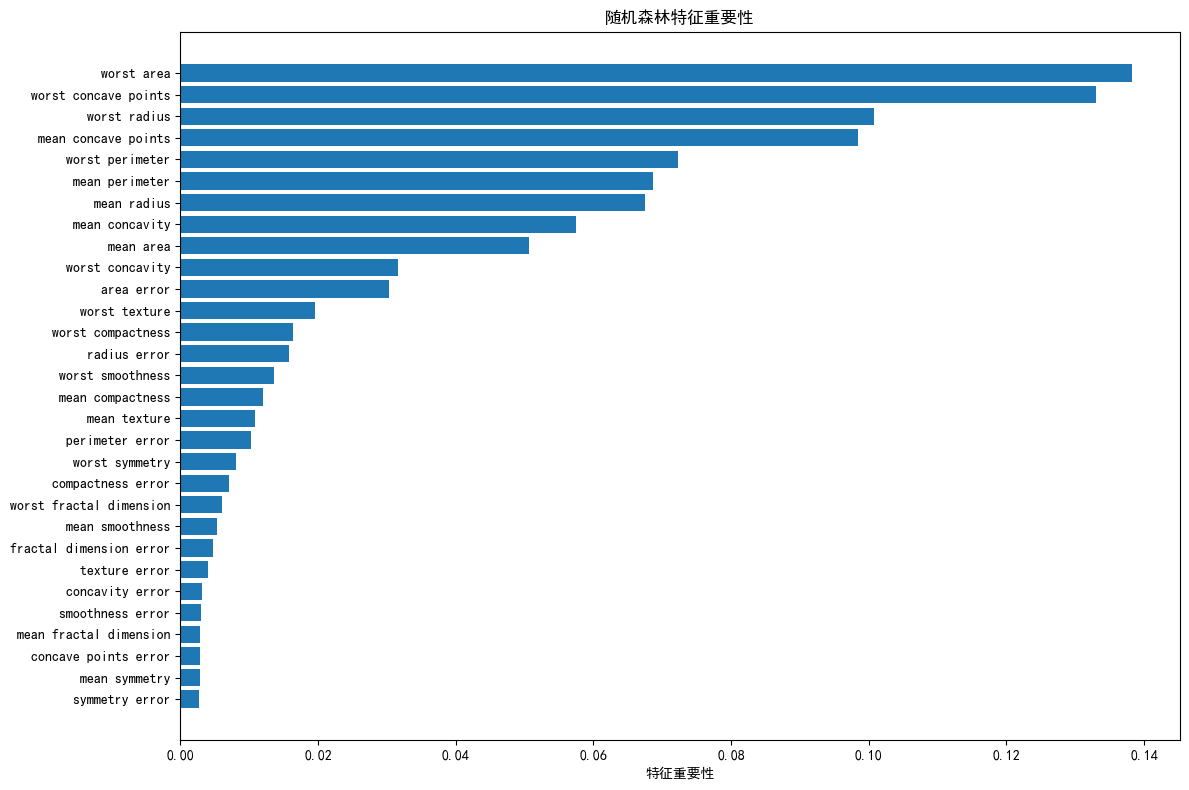

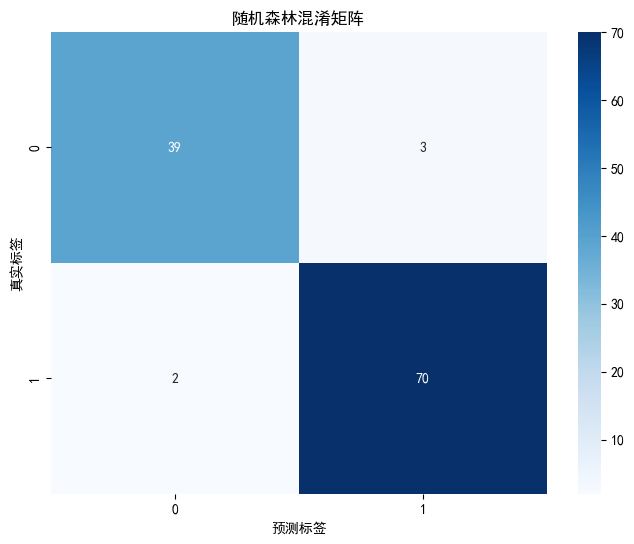

In [2]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['font.sans-serif'] = ['SimHei']  # 使用黑体
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题
# 创建随机森林模型
rf = RandomForestClassifier(n_estimators=100, # 基学习器数量
max_depth=5, # 最大深度
random_state=42)
# 训练模型
rf.fit(X_train_scaled, y_train)
# 预测与评估
y_pred_rf = rf.predict(X_test_scaled)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"随机森林准确率: {accuracy_rf:.4f}")
# 特征重要性可视化
plt.figure(figsize=(12, 8))
sorted_idx = rf.feature_importances_.argsort()
plt.barh(feature_names[sorted_idx], rf.feature_importances_[sorted_idx])
plt.xlabel("特征重要性")
plt.title("随机森林特征重要性")
plt.tight_layout()
plt.show()
# 混淆矩阵
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues')
plt.xlabel('预测标签')
plt.ylabel('真实标签')
plt.title('随机森林混淆矩阵')
plt.show()

## 3. Boosting实现（AdaBoost）

AdaBoost准确率: 0.9561


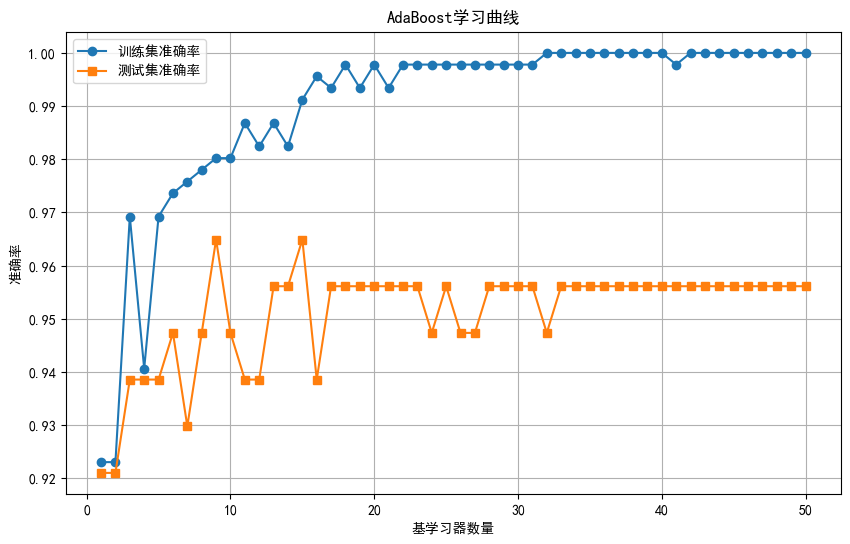

In [3]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
# 创建AdaBoost模型
adaboost = AdaBoostClassifier(
 estimator=DecisionTreeClassifier(max_depth=1), # 基学习器（决策树桩）
 n_estimators=50, # 基学习器数量
 learning_rate=0.8, # 学习率
 random_state=42)
# 训练模型
adaboost.fit(X_train_scaled, y_train)
# 预测与评估
y_pred_ab = adaboost.predict(X_test_scaled)
accuracy_ab = accuracy_score(y_test, y_pred_ab)
print(f"AdaBoost准确率: {accuracy_ab:.4f}")
# 绘制学习曲线
train_scores = []
test_scores = []
for n in range(1, 51):
    adaboost.n_estimators = n
    adaboost.fit(X_train_scaled, y_train)
    train_scores.append(adaboost.score(X_train_scaled, y_train))
    test_scores.append(adaboost.score(X_test_scaled, y_test))
plt.figure(figsize=(10, 6))
plt.plot(range(1, 51), train_scores, 'o-', label='训练集准确率')
plt.plot(range(1, 51), test_scores, 's-', label='测试集准确率')
plt.xlabel('基学习器数量')
plt.ylabel('准确率')
plt.title('AdaBoost学习曲线')
plt.legend()
plt.grid(True)
plt.show()

## 4. 模型对⽐分析

逻辑回归测试准确率: 0.9825
支持向量机测试准确率: 0.9825
随机森林测试准确率: 0.9561
AdaBoost测试准确率: 0.9561


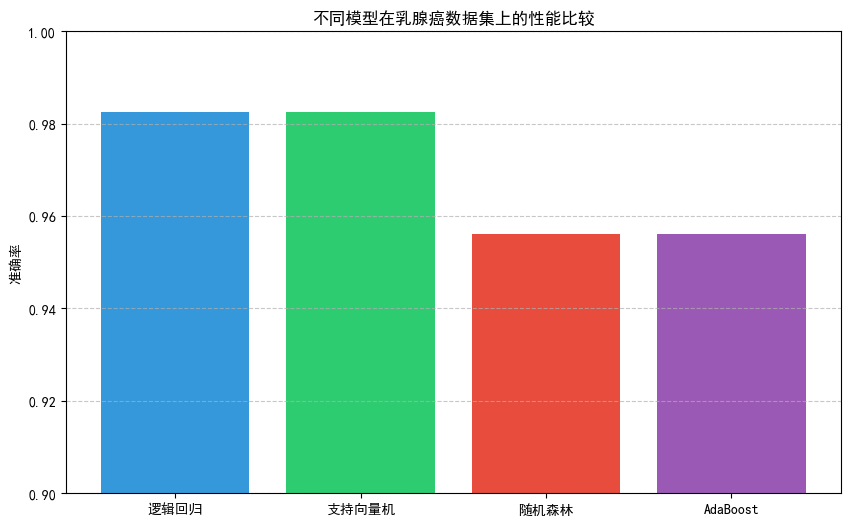

In [4]:
# 对比不同模型性能
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
# 创建对比模型
models = {
 "逻辑回归": LogisticRegression(max_iter=1000, random_state=42),
 "支持向量机": SVC(probability=True, random_state=42),
 "随机森林": RandomForestClassifier(n_estimators=100, random_state=42),
 "AdaBoost": AdaBoostClassifier(n_estimators=50, random_state=42)
}
# 训练并评估模型
results = {}
for name, model in models.items():
 model.fit(X_train_scaled, y_train)
 score = model.score(X_test_scaled, y_test)
 results[name] = score
 print(f"{name}测试准确率: {score:.4f}")
# 可视化模型比较
plt.figure(figsize=(10, 6))
plt.bar(results.keys(), results.values(), 
color=['#3498db', '#2ecc71', '#e74c3c', '#9b59b6'])
plt.ylabel('准确率')
plt.title('不同模型在乳腺癌数据集上的性能比较')
plt.ylim(0.9, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## 5. 实验分析 
- ⽰例分析：基学习器数量影响

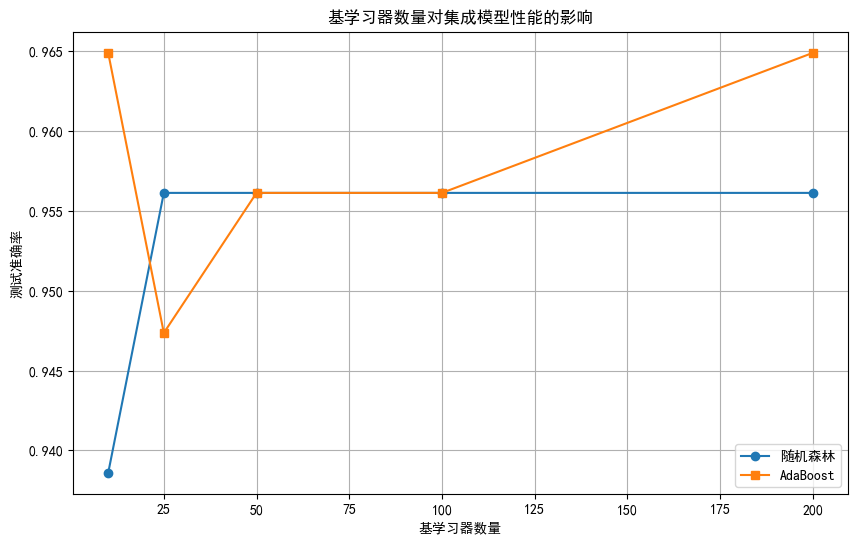

In [5]:
n_estimators_range = [10, 25, 50, 100, 200]
rf_scores = []
ab_scores = []
for n in n_estimators_range:
 # 随机森林
 rf = RandomForestClassifier(n_estimators=n, random_state=42)
 rf.fit(X_train_scaled, y_train)
 rf_scores.append(rf.score(X_test_scaled, y_test))
 
 # AdaBoost
 ab = AdaBoostClassifier(n_estimators=n, random_state=42)
 ab.fit(X_train_scaled, y_train)
 ab_scores.append(ab.score(X_test_scaled, y_test))
# 绘制比较图
plt.figure(figsize=(10, 6))
plt.plot(n_estimators_range, rf_scores, 'o-', label='随机森林')
plt.plot(n_estimators_range, ab_scores, 's-', label='AdaBoost')
plt.xlabel('基学习器数量')
plt.ylabel('测试准确率')
plt.title('基学习器数量对集成模型性能的影响')
plt.legend()
plt.grid(True)
plt.show()

# 实验要求

## 必做任务

1. **实现两种集成方法：**  
    - 使用随机森林（Bagging）进行分类  
    - 使用AdaBoost（Boosting）进行分类  
    - 对比两种方法的预测性能

2. **模型评估与分析：**  
    - 在乳腺癌数据集上训练两种集成模型  
    - 评估模型在测试集上的准确率  
    - 可视化特征重要性和混淆矩阵

3. **参数影响分析：**  
    - 调整随机森林的 `n_estimators` 参数（10-200），分析对性能的影响  
    - 调整AdaBoost的 `learning_rate` 参数（0.01-1.0），分析对学习过程的影响

## 扩展任务

1. **多数据集测试：**  
    - 在葡萄酒识别数据集上测试集成学习方法  
    - 在鸢尾花数据集上测试集成学习方法  
    - 比较不同数据集上的表现差异

2. **高级集成方法：**  
    - 实现Gradient Boosting（GBDT）算法  
    - 比较GBDT与AdaBoost的性能差异

3. **回归问题应用：**  
    - 使用集成学习方法解决波士顿房价回归问题  
    - 评估模型的均方误差（MSE）和R²分数

4. **噪声数据分析：**  
    - 在数据中添加噪声，测试集成学习的鲁棒性  
    - 比较集成模型与单一模型的抗噪声能力

## 预期结果分析

1. **随机森林（Bagging）：**
    - 增加基学习器数量通常能提升模型性能
    - 存在收益递减点（通常100个左右）
    - 对过拟合有较强抵抗力

2. **AdaBoost（Boosting）：**
    - 增加基学习器数量能持续提升性能
    - 更容易出现过拟合（需谨慎选择学习率）
    - 对噪声数据更敏感

3. **性能对比：**
    - 在多数分类任务中，集成方法优于单一模型
    - 随机森林通常训练更快，更易调参
    - Boosting方法在精心调参后可能达到更高精度


# 思考题

1. **集成策略差异：**  
    - 为什么 Bagging 能有效降低模型方差？  
      > Bagging 通过对数据集进行有放回采样，训练多个基学习器并对结果进行集成，能有效减少单一模型对训练数据的依赖，从而降低模型方差，提高泛化能力。
    - 为什么 Boosting 能有效减少模型偏差？  
      > Boosting 通过串行训练基学习器，每一轮关注前一轮错误样本，逐步修正模型的预测，使整体模型的偏差不断减小。

2. **参数调优：**  
    - 如何选择随机森林中的基学习器数量？  
      > 一般通过交叉验证或绘制学习曲线，选择使模型性能趋于稳定且计算成本可接受的基学习器数量，通常在100左右即可满足大多数任务。
    - AdaBoost 的学习率参数如何影响模型性能？  
      > 学习率越大，模型对每个基学习器的权重调整越大，容易过拟合；学习率过小则收敛变慢，需增加基学习器数量。需结合实验调优。

3. **基学习器选择：**  
    - 为什么决策树常被用作集成学习的基学习器？  
      > 决策树结构简单、训练速度快、对特征类型要求低，且易于捕捉数据的非线性关系，适合作为集成方法的基学习器。
    - 使用其他基学习器（如 SVM）会有何不同？  
      > SVM 等复杂模型作为基学习器时，训练成本高，且集成效果未必优于简单模型，可能导致过拟合或计算效率低下。

4. **过拟合问题：**  
    - 集成学习方法如何应对过拟合风险？  
      > Bagging 通过样本扰动和模型集成降低过拟合风险，Boosting 可通过正则化、降低学习率等方式缓解过拟合。
    - Bagging 和 Boosting 哪个更容易过拟合？为什么？  
      > Boosting 更容易过拟合，尤其在基学习器复杂或学习率过大时，因为它不断强化难以正确分类的样本，可能对噪声过度拟合。

5. **实际应用：**  
    - 在什么场景下应优先选择 Bagging 方法？  
      > 当模型方差较大、数据噪声较多或需提升模型稳定性时，优先选择 Bagging（如随机森林）。
    - 在什么场景下应优先选择 Boosting 方法？  
      > 当模型偏差较大、需提升模型精度且数据噪声较少时，优先选择 Boosting（如AdaBoost、GBDT）。


# 扩展阅读

1. **高级集成方法：**  
    - 梯度提升决策树（GBDT）  
    - 极限梯度提升（XGBoost）  
    - 轻量级梯度提升机（LightGBM）  

2. **实际应用案例：**  
    - Kaggle竞赛中的集成学习应用  
    - 金融风控中的集成模型  
    - 医疗诊断中的集成决策系统  

3. **理论进阶：**  
    - 集成学习的误差-分歧分解  
    - 多样性增强技术  
    - 动态分类器选择  